In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

%load_ext autoreload
%autoreload 2

## Train a single model

#### Load the training and testing datasets and tokenize them

In [ ]:

VOCAB_SIZE = 100
N_TRAIN = 2*40_000
N_TEST = 1000

from models import ChronosTokenizer
tokenizer = ChronosTokenizer(VOCAB_SIZE, -3, 3)

traj_train = np.load("data/traj_train.pkl", allow_pickle=True)
x_train = traj_train[:, 0]
tok_train, aux = tokenizer.encode_series(x_train, 100, 10)

traj_test = np.load("data/traj_test.pkl", allow_pickle=True)
x_test = traj_test[:, 0]
tok_test, aux = tokenizer.encode_series(x_test, 100, 10)


traj_test_out = np.load("data/traj_test_out.pkl", allow_pickle=True)
x_test_out = traj_test_out[:, 0]
tok_test_out, aux = tokenizer.encode_series(x_test_out, 100, 10)



### Import the model and train it

In [1]:
CONTEXT_LENGTH = 32*4

In [ ]:
import torch
from models import TinyCausalLM, train_next_token

CONTEXT_LENGTH = 32*4

torch.manual_seed(0)
tokens = torch.tensor(tok_train, dtype=torch.long)
tokens_val = torch.tensor(tok_test, dtype=torch.long)
tokens_test_out = torch.tensor(tok_test_out, dtype=torch.long)
model, losses, val_losses, val_losses_ood = train_next_token(tokens, tokens_val[:N_TEST], tokens_test_out[:N_TEST], vocab_size=(1 + VOCAB_SIZE), 
                                                                block_size=CONTEXT_LENGTH, lr=1e-4, batch_size=64*2, steps=60000, d_model=128 * 2, d_k=64, weight_decay=1e0,
                                                                save_path="./private_data/training_run/"
                                                                )

plt.figure(figsize=(10, 5))
plt.semilogy(losses, label="Train data in-domain")
plt.semilogy(val_losses, label="Test data in-domain")
plt.semilogy(val_losses_ood, label="Test data out-of-domain")
plt.ylim(1, None)
plt.xlabel("Training steps")
plt.ylabel("Loss")
plt.legend(frameon=False)


## Optionally save the model
# from models import save_checkpoint
# losses = np.array([losses, val_losses, val_losses_ood]).T
# losses.dump(f"losses.npz")
# ckpt_name = f"tiny_lm.pt"
# save_checkpoint(ckpt_name, model)



Using MPS
step 100 | train loss 11.4984 | val loss 10.8745 | val ood loss 11.2325
step 200 | train loss 3.2562 | val loss 3.1957 | val ood loss 3.8945
step 300 | train loss 2.7337 | val loss 2.6582 | val ood loss 3.8470
step 400 | train loss 2.3349 | val loss 2.2633 | val ood loss 4.5450
step 500 | train loss 1.9756 | val loss 1.9882 | val ood loss 5.7386
step 600 | train loss 1.7224 | val loss 1.7905 | val ood loss 6.4033
step 700 | train loss 1.5458 | val loss 1.6471 | val ood loss 7.0577
step 800 | train loss 1.4173 | val loss 1.5284 | val ood loss 7.3573
step 900 | train loss 1.3339 | val loss 1.4683 | val ood loss 7.6853
step 1000 | train loss 1.3124 | val loss 1.3988 | val ood loss 7.4819
step 1100 | train loss 1.2318 | val loss 1.3504 | val ood loss 7.5008
step 1200 | train loss 1.1840 | val loss 1.3062 | val ood loss 7.8246
step 1300 | train loss 1.1284 | val loss 1.2622 | val ood loss 7.7125
step 1400 | train loss 1.0554 | val loss 1.2532 | val ood loss 8.0700
step 1500 | trai

In [ ]:
plt.figure(figsize=(10, 5))
plt.loglog(1 + np.arange(len(losses)), losses, label="Train data in-domain")
plt.semilogy(1 + np.arange(len(losses)), val_losses, label="Test data in-domain")
plt.semilogy(1 + np.arange(len(losses)), val_losses_ood, label="Test data out-of-domain")
plt.xlabel("Training steps")
plt.ylabel("Loss")
plt.legend(frameon=False)

Text(0.5, 1.0, 'Rossler: Out-of-domain')

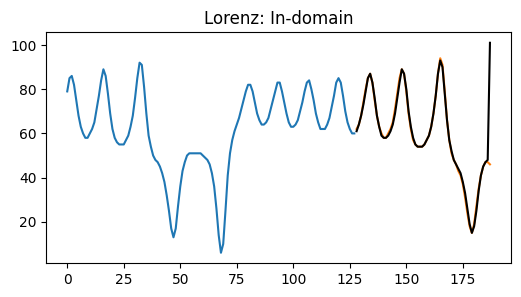

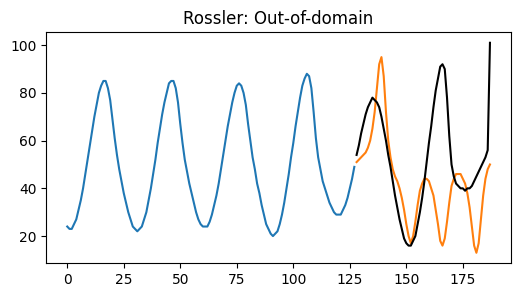

In [ ]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def generate_autoregressive(
    model,
    context_ids: torch.LongTensor,           # (T,) or (B,T)
    max_new_tokens: int,
    decode: str = "sample",                  # {"sample","greedy","expectation"}
    temperature: float = 1.0,                # tune on val set if using "sample"
    value_bins: torch.Tensor | None = None,  # (V,) bin centers for "expectation"
):
    """
    Autoregressive generation for time-series models that emit discrete bins.

    Args:
        model: Callable mapping (B,T) -> logits (B,T,V). Must have .block_size.
        context_ids: Initial context, shape (T,) or (B,T).
        max_new_tokens: Horizon H.
        decode: "sample" draws from the full predictive distribution (recommended
            for probabilistic forecasts); "greedy" takes the modal bin (point
            forecast via mode); "expectation" returns the mean-bin index under
            p(y_t|y_<t) (point forecast via mean).  No top-k/top-p truncation.
        temperature: Temperature applied as logits /= max(temperature, 1e-8).
        value_bins: Bin centers used to compute the expectation when
            decode="expectation". If None, expectation returns the argmax index.

    Returns:
        torch.LongTensor of shape (B, T + H) with generated token ids.
    """
    device = next(model.parameters()).device
    x = context_ids.to(device)
    if x.ndim == 1:
        x = x.unsqueeze(0)  # (1,T)

    model.eval()
    for _ in range(max_new_tokens):
        x_cond = x[:, -model.block_size:]
        logits = model(x_cond)[:, -1, :]  # (B,V)

        if temperature != 1.0:
            logits = logits / max(temperature, 1e-8)

        if decode == "greedy":
            next_id = torch.argmax(logits, dim=-1)  # (B,)
        else:
            probs = F.softmax(logits, dim=-1)       # (B,V)

            if decode == "expectation":
                if value_bins is None:
                    # fall back to argmax index if no bin values provided
                    next_id = torch.argmax(probs, dim=-1)
                else:
                    # pick the index of the closest bin to the expected value
                    mean_vals = (probs * value_bins.to(device)).sum(dim=-1)      # (B,)
                    # map back to nearest bin index
                    diffs = (mean_vals.unsqueeze(-1) - value_bins.to(device))**2 # (B,V)
                    next_id = torch.argmin(diffs, dim=-1)
            else:  # "sample"
                next_id = torch.multinomial(probs, num_samples=1).squeeze(-1)   # (B,)

        x = torch.cat([x, next_id.unsqueeze(-1)], dim=-1)

    return x

from models import generate_autoregressive

context_length = model.block_size
horizon = 60
t_inds = np.arange(context_length + horizon)

## In-distribution
ctx = torch.tensor(tok_test[-(context_length+horizon):-horizon], dtype=torch.long)  # (T,)
out = generate_autoregressive(model, ctx, max_new_tokens=horizon, decode="greedy")

## Out-of-distribution
ctx_ood = torch.tensor(tok_test_out[-(context_length+horizon):-horizon], dtype=torch.long)  # (T,)
out_ood = generate_autoregressive(model, ctx_ood, max_new_tokens=horizon, decode="greedy")

plt.figure(figsize=(6, 3))
plt.plot(t_inds[:context_length], out[0].tolist()[:context_length])
plt.plot(t_inds[context_length:context_length+horizon], out[0].tolist()[context_length:context_length+horizon])
plt.plot(t_inds[context_length:context_length+horizon], tok_test[-horizon:], color='black')
plt.title("Lorenz: In-domain")

plt.figure(figsize=(6, 3))
plt.plot(t_inds[:context_length], out_ood[0].tolist()[:context_length])
plt.plot(t_inds[context_length:context_length+horizon], out_ood[0].tolist()[context_length:context_length+horizon])
plt.plot(t_inds[context_length:context_length+horizon], tok_test_out[-horizon:], color='black')
plt.title("Rossler: Out-of-domain")